In [1]:
#Dimension reduction

image = h*w (2D)

 = h* w *d (3D)

 = h* w *d *t (4D)

pca = principle component analysis

unsupervised

only input data hercha

steps of pca
1. calcaulate mean of every feature
2. calculate the covariance matrix
3. calculate the eigen values and eigen vectors
4. choose principle components
5. projected data onto principle component


In [2]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [3]:
df = sns.load_dataset("titanic")

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [6]:
#only numeric features

X = df[[ 'pclass', 'age', 'sibsp', 'parch', 'fare']]

In [7]:
X.head()

,pclass,age,sibsp,parch,fare
0,3,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,3,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,3,35.0,0,0,8.0500


In [8]:
X.isnull().sum()

,0
pclass,0
age,177
sibsp,0
parch,0
fare,0


In [9]:
#fill missing values
X = X.fillna(X.mean())

In [10]:
X.isnull().sum()

,0
pclass,0
age,0
sibsp,0
parch,0
fare,0


In [11]:
#standarize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_scaled

array([[ 0.82737724, -0.5924806 ,  0.43279337, -0.47367361, -0.50244517],
       [-1.56610693,  0.63878901,  0.43279337, -0.47367361,  0.78684529],
       [ 0.82737724, -0.2846632 , -0.4745452 , -0.47367361, -0.48885426],
       ...,
       [ 0.82737724,  0.        ,  0.43279337,  2.00893337, -0.17626324],
       [-1.56610693, -0.2846632 , -0.4745452 , -0.47367361, -0.04438104],
       [ 0.82737724,  0.17706291, -0.4745452 , -0.47367361, -0.49237783]])

In [13]:
#apply PCA
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

In [14]:
X_pca

array([[ 1.15080251, -0.06919074, -0.20360737],
       [-1.75860564,  0.14288499, -0.09564774],
       [ 0.88943917, -0.71829878, -0.21081334],
       ...,
       [ 0.78793795,  1.39908707,  1.05658623],
       [-0.9883165 , -0.42381037, -0.80737927],
       [ 0.68237268, -0.86735995,  0.16142685]])

In [15]:
pca_df = pd.DataFrame(X_pca, columns = ['PC1', 'PC2', 'PC3'])
pca_df.head()

,PC1,PC2,PC3
0,1.150803,-0.069191,-0.203607
1,-1.758606,0.142885,-0.095648
2,0.889439,-0.718299,-0.210813
3,-1.448581,0.081721,-0.157688
4,0.574460,-0.939013,0.344915


In [16]:
#Explained variance
print("\n Explained variance ratio:")
print(pca.explained_variance_ratio_)


 Explained variance ratio:
[0.3380521  0.32598107 0.14491373]


In [17]:
#LDA (Linear discriminant analysis)

steps for LDA
1. calculate the mean vectors for each class
2. compute the covariance of each class
3. compute the within class scatter matric
4. compute the between class scatter matric
5. find eigen values and choose top eigen value

find eigen vectors

find the dot product of data points with eigen vectors

In [18]:

y = df["survived"]

In [19]:
#n_components < min (n_features, n_classes -1)

In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components = 1)
X_lda = lda.fit_transform(X_scaled, y)

In [21]:
lda_df = pd.DataFrame(X_lda, columns = ["LD1"])
lda_df.head()

,LD1
0,-0.782780
1,1.109609
2,-0.712100
3,1.157592
4,-1.092297


explained variance ratio (first two components): [0.92461872 0.05306648]


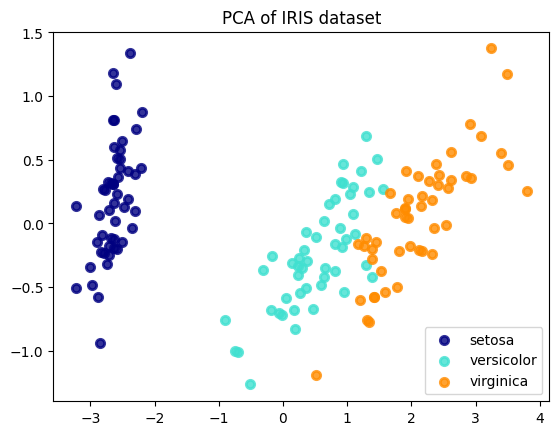

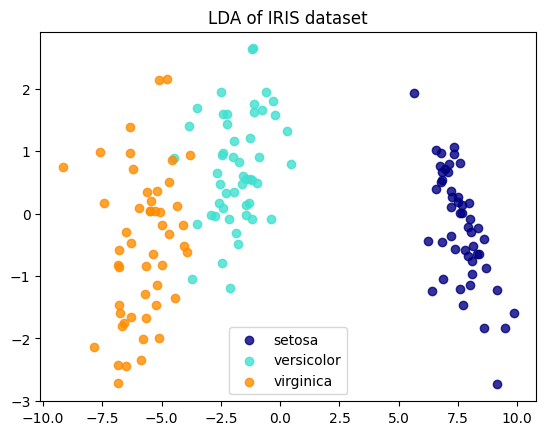

In [22]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

iris = datasets.load_iris()

X = iris.data
y = iris.target
target_names = iris.target_names

pca = PCA(n_components=2)
X_r = pca.fit(X).transform(X)

lda = LinearDiscriminantAnalysis(n_components=2)
X_r2 = lda.fit(X, y).transform(X)

# Percentage of variance explained for each components
print(
    "explained variance ratio (first two components): %s"
    % str(pca.explained_variance_ratio_)
)

plt.figure()
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("PCA of IRIS dataset")

plt.figure()
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(
        X_r2[y == i, 0], X_r2[y == i, 1], alpha=0.8, color=color, label=target_name
    )
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("LDA of IRIS dataset")

plt.show()

In [23]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  